### Astrostatistic Lecture 4 

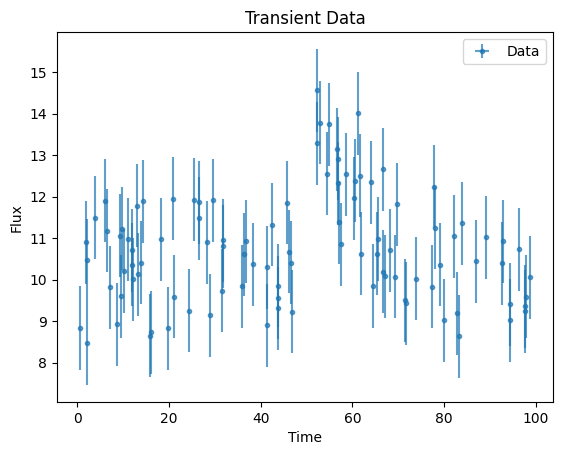

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from scipy import stats
import emcee
import corner
import dynesty
from sklearn.neighbors import KernelDensity
import matplotlib.patches as mpatches
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
plt.rcParams['figure.facecolor'] = 'white' #custom plot stuff
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'         
plt.rcParams['axes.labelcolor'] = 'black'  
plt.rcParams['text.color'] = 'black'  
plt.rcParams['xtick.color'] = 'black'           
plt.rcParams['ytick.color'] = 'black'

#same data as Lecture 11
data = np.load('/home/ricca/astrostat/astrostatistics_bicocca_2026/solutions/transient.npy') #load data
time = data[:,0]
flux = data[:,1]
errors = np.ones_like(flux)

plt.errorbar(time, flux, errors, 0,  '.', alpha = 0.7, label = 'Data')
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.title('Transient Data')
plt.show()

In [21]:
#now we need to do it using dynesty so using nested sampling 
def model_exp(A, b, t, t0, alfa):   #define the model to use
    return np.where(t < t0, b, b + A * np.exp(-alfa*(t - t0)))

def log_likelihood(theta, t, data, errors, model):     #log of a gaussian likelihood
    A, b, t0, log_alfa = theta
    alfa = np.exp(log_alfa)
    if model == 'exp':
        m = model_exp(A, b, t, t0, alfa)    #likelihood of the model given the data we have and the errors (equal but whatever)
        return -0.5 * np.sum((data - m)**2 / errors**2)
    else:
        raise ValueError("Lo faccio dopo")
    
def transformer (x):
    a = stats.uniform.ppf(x[0], 0, 50)
    b = stats.uniform.ppf(x[1], 0, 50)
    t0 = stats.uniform.ppf(x[2], 0, 100)
    alfa = stats.uniform.ppf(x[3], -5, 5)
    return np.array([a, b, t0, alfa])

In [22]:
ndim=4

sampler = dynesty.NestedSampler(log_likelihood, transformer, ndim, logl_args=[time, flux, errors, 'exp'])
sampler.run_nested()
sresults = sampler.results

3771it [00:35, 21.42it/s, bound: 86 | nc: 216 | ncall: 65600 | eff(%):  5.748 | loglstar:   -inf < -87.064 <    inf | logz: -95.884 +/-  0.126 | dlogz: 38.929 >  0.509]      /home/ricca/astrostat/astrostatistics_bicocca_2026/venv/lib/python3.12/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
7175it [00:56, 127.19it/s, +500 | bound: 145 | nc: 1 | ncall: 96650 | eff(%):  7.982 | loglstar:   -inf < -48.761 <    inf | logz: -62.323 +/-  0.161 | dlogz:  0.001 >  0.509]


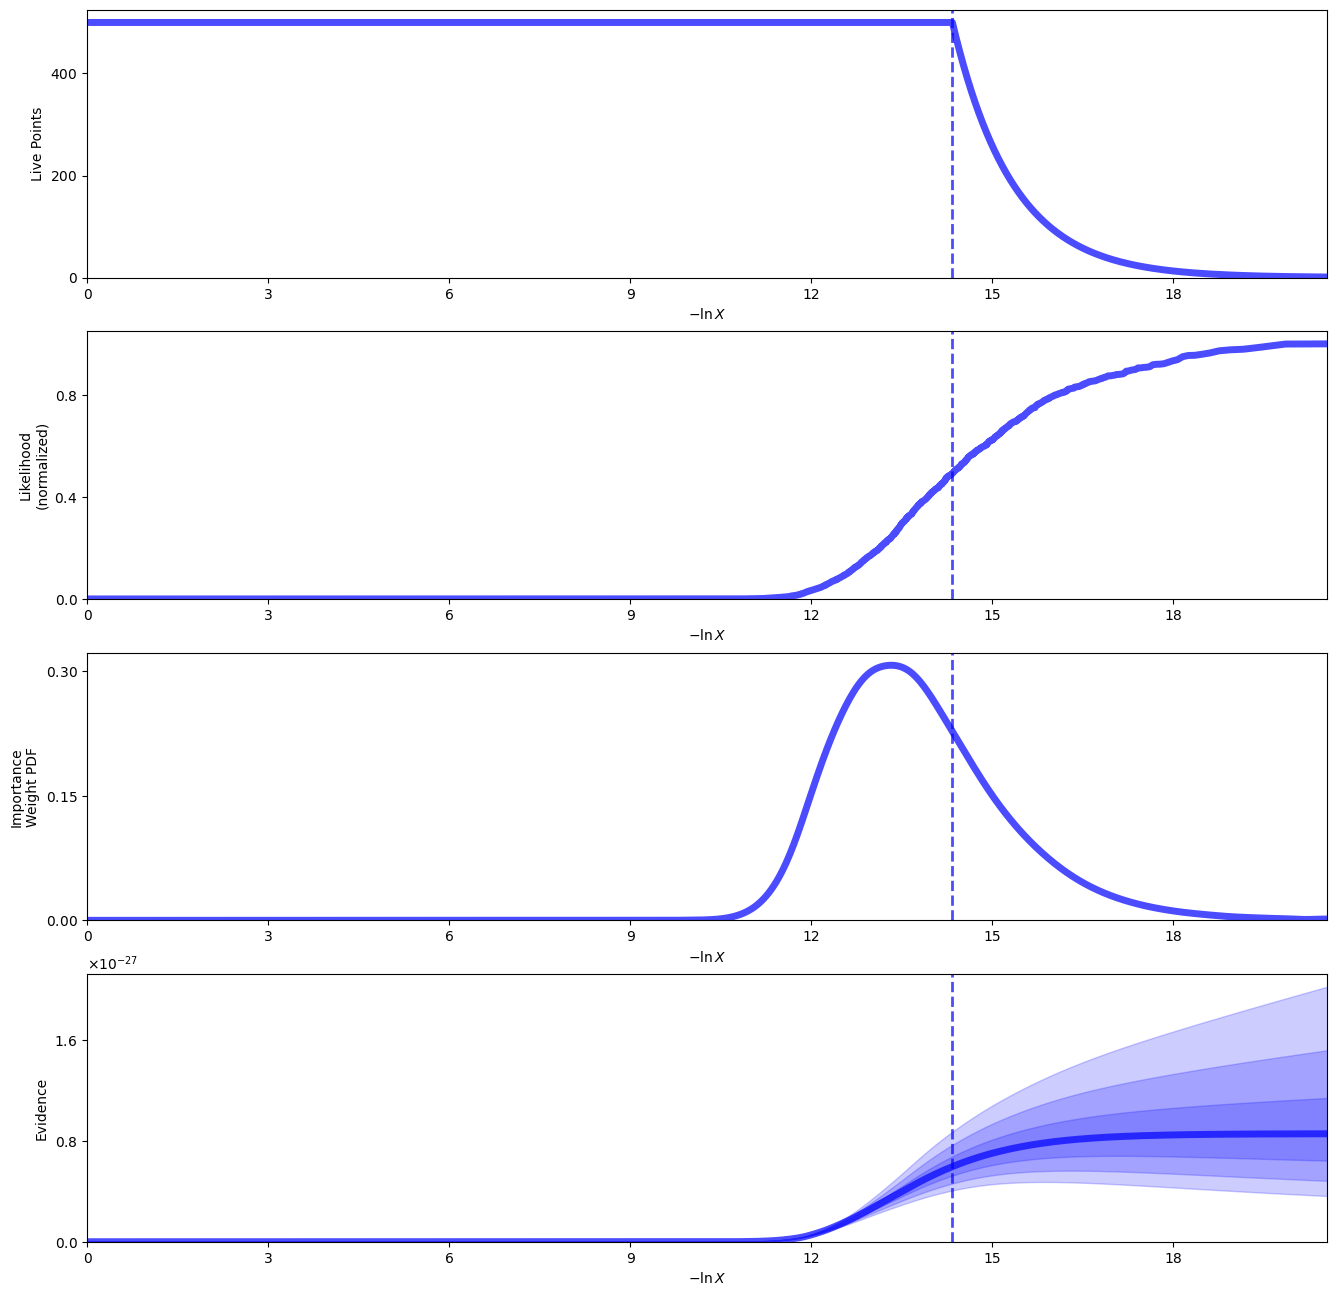

In [27]:
rfig, raxes = dyplot.runplot(sresults)

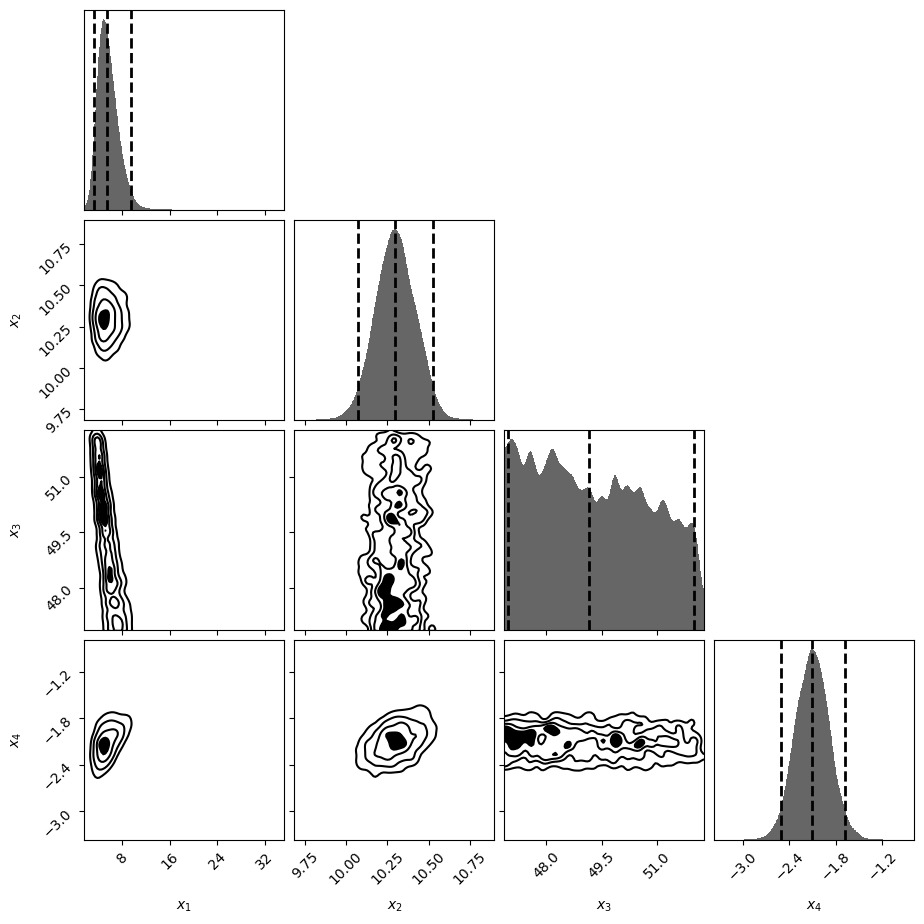

In [28]:
cfig, caxes = dyplot.cornerplot(sresults)

Bayesian evidence 8.579912162591864e-28
68% parameter credible regions are:
 ['A', 'b', 't0', 'alfa'] [[4.101370786638509, 7.188449328769185], [10.179138148278165, 10.420806458711665], [47.53946427171819, 51.07759042354115], [-2.3136296729353676, -1.8898010695061298]]



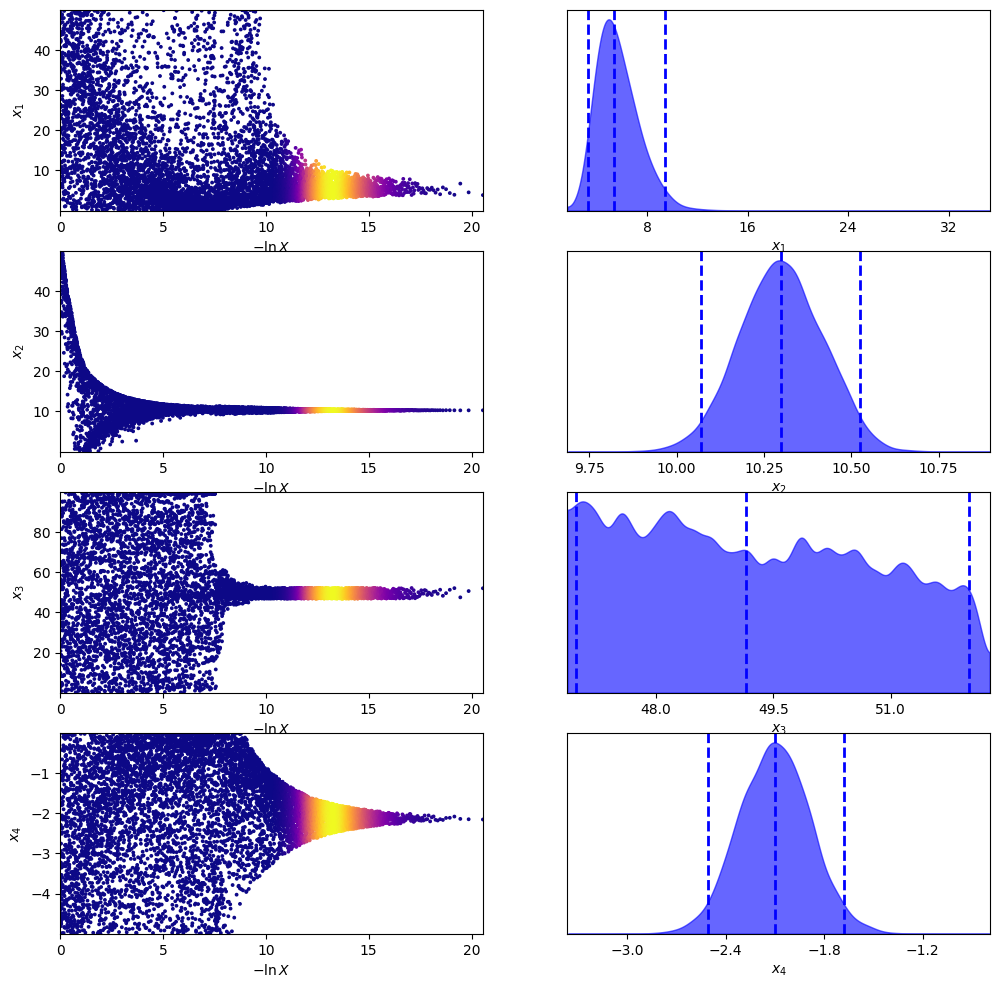

In [36]:
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

evidence = sresults.logz[-1] #evidence
print("Bayesian evidence", np.exp(evidence))

samples_equal = dyfunc.resample_equal(samples, weights)
tfig, taxes = dyplot.traceplot(sresults)
labels = ['A', 'b', 't0', 'alfa']

quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n '+ str(labels) + ' '+ str(quantiles) + '\n')